In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data=pd.read_csv('insurance.csv')
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [3]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
from sklearn.preprocessing import OneHotEncoder
Hot=OneHotEncoder(sparse_output=False)
encode=data[['sex','smoker','region']]
encoded_data=Hot.fit_transform(encode)
encoded_df=pd.DataFrame(encoded_data,columns=Hot.get_feature_names_out())

In [5]:
new_data=pd.concat([data.drop(['sex','smoker','region'],axis=1),encoded_df],axis=1)
new_data

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1334,18,31.920,0,2205.98080,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1335,18,36.850,0,1629.83350,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,21,25.800,0,2007.94500,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [13]:
X=new_data.drop('charges',axis=1)
Y=new_data['charges']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

<Axes: >

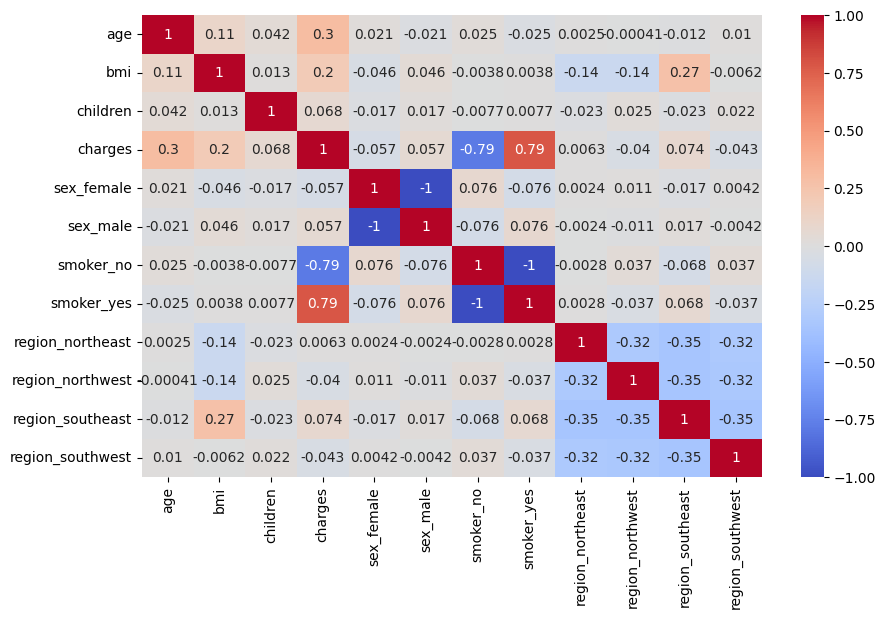

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(new_data.corr(),annot=True,cmap='coolwarm')

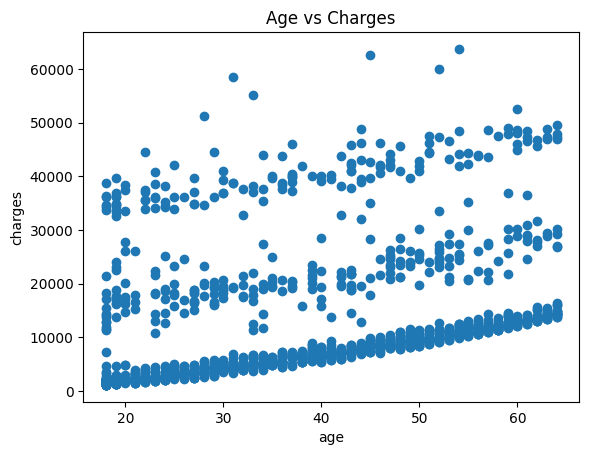

In [15]:
plt.scatter(data['age'],data['charges'])
plt.xlabel('age')
plt.ylabel('charges')
plt.title('Age vs Charges')
plt.show()

In [16]:
data['sex'].value_counts()
data['smoker'].value_counts()
data['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

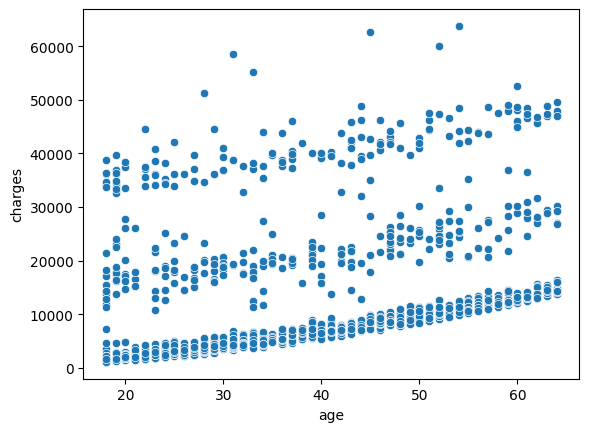

In [17]:
sns.scatterplot(x='age', y='charges', data=data)
plt.show()

In [18]:
#Applying Models
from sklearn.linear_model import LinearRegression as LIR,LogisticRegression as LOR
from sklearn.tree import DecisionTreeRegressor as DTR,DecisionTreeClassifier as DTC
from sklearn.svm import SVR,SVC
from sklearn.neighbors import KNeighborsClassifier as KNC,KNeighborsRegressor as KNR
from sklearn.ensemble import RandomForestRegressor as RFR,RandomForestClassifier as RFC
from sklearn.ensemble import GradientBoostingClassifier as GBC,GradientBoostingRegressor as GBR
from xgboost import XGBClassifier as XGBC,XGBRegressor as XGBR

In [19]:
from sklearn.metrics import root_mean_squared_error,accuracy_score,confusion_matrix,f1_score,precision_score,recall_score,classification_report,mean_absolute_error,r2_score,mean_squared_error
result_class=[]
confusion=[]
result_reg=[]
#Function for Classification use models 
def perform_class(model,Y_test,Y_pred):
        acc=accuracy_score(Y_test,Y_pred)
        pre=precision_score(Y_test,Y_pred,average='weighted')
        r_s=recall_score(Y_test,Y_pred,average='weighted')
        f1=f1_score(Y_test,Y_pred,average='weighted')
        cnf=confusion_matrix(Y_test,Y_pred)
        print(f'Accuracy_score of {model}:-',acc)
        print(f'Confusion_matrix of {model}:-\n',confusion_matrix(Y_test,Y_pred))
        print(f'Precision_score of {model}:-',pre)
        print(f'Recall_score of {model}:-',r_s)
        print(f'f1_score of {model}:-',f1)
        print(f'Classification report of {model}:-\n',classification_report(Y_test,Y_pred))
        result_class.append([model,acc,pre,r_s,f1])
        confusion.append(cnf)
#Function for Regression use models
def perform_Reg(model,Y_test,Y_pred):
    mae=mean_absolute_error(Y_test,Y_pred)
    mse=mean_squared_error(Y_test,Y_pred)
    rmse=root_mean_squared_error(Y_test,Y_pred)
    r2=r2_score(Y_test,Y_pred)
    print(f'Mean absolute error for this {model} is:-',mae)
    print(f'R2_score for this {model} is:-',r2)
    print(f'Mean Squared error for this {model} is:-',mse)
    result_reg.append([model,mae,mse,rmse,r2])
class_model=[LOR(),SVC(),DTC(),KNC(),RFC(),GBC(),XGBC()]
Reg_model=[LIR(),SVR(),DTR(),KNR(),RFR(),GBR(),XGBR()]
select=int(input('Select Operation:-1 for classification,2 for Regression'))
if select==1:
    for model in class_model:
        model.fit(X_train,Y_train)
        Y_pred=model.predict(X_test)
        perform_class(model,Y_test,Y_pred)
    
elif select==2:
    for model in Reg_model:
        model.fit(X_train,Y_train)
        Y_pred=model.predict(X_test)
        perform_Reg(model,Y_test,Y_pred)
        from sklearn.linear_model import LinearRegression as LR
else:
    print('wrong input')

Select Operation:-1 for classification,2 for Regression 2


Mean absolute error for this LinearRegression() is:- 4181.194473753645
R2_score for this LinearRegression() is:- 0.7835929767120723
Mean Squared error for this LinearRegression() is:- 33596915.85136147
Mean absolute error for this SVR() is:- 8598.964701526631
R2_score for this SVR() is:- -0.07248639351177277
Mean Squared error for this SVR() is:- 166502152.13488975
Mean absolute error for this DecisionTreeRegressor() is:- 3275.2809959664182
R2_score for this DecisionTreeRegressor() is:- 0.6879483354884839
Mean Squared error for this DecisionTreeRegressor() is:- 48445625.07530936
Mean absolute error for this KNeighborsRegressor() is:- 6683.390927511195
R2_score for this KNeighborsRegressor() is:- 0.2972815213350175
Mean Squared error for this KNeighborsRegressor() is:- 109096152.40856743
Mean absolute error for this RandomForestRegressor() is:- 2543.336904726182
R2_score for this RandomForestRegressor() is:- 0.8615728779126081
Mean Squared error for this RandomForestRegressor() is:- 214

In [23]:
result1_df=pd.DataFrame(result_class,columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

result2_df=pd.DataFrame(result_reg,columns=['Model','MAE','MSE','RMSE','R2_score'])
result2_df

,Model,MAE,MSE,RMSE,R2_score
0,LinearRegression(),4181.194474,3.359692e+07,5796.284659,0.783593
1,SVR(),8598.964702,1.665022e+08,12903.571294,-0.072486
2,DecisionTreeRegressor(),3275.280996,4.844563e+07,6960.289152,0.687948
3,KNeighborsRegressor(),6683.390928,1.090962e+08,10444.910359,0.297282
4,"(DecisionTreeRegressor(max_features=1.0, rando...",2543.336905,2.149064e+07,4635.799295,0.861573
5,([DecisionTreeRegressor(criterion='friedman_ms...,2406.795226,1.873949e+07,4328.913000,0.879294
6,"XGBRegressor(base_score=None, booster=None, ca...",2604.333804,2.245442e+07,4738.609614,0.855365


In [24]:
best_model=result2_df.iloc[result2_df['R2_score'].idxmax()]
print(best_model)

Model       ([DecisionTreeRegressor(criterion='friedman_ms...
MAE                                               2406.795226
MSE                                           18739487.764532
RMSE                                                 4328.913
R2_score                                             0.879294
Name: 5, dtype: object


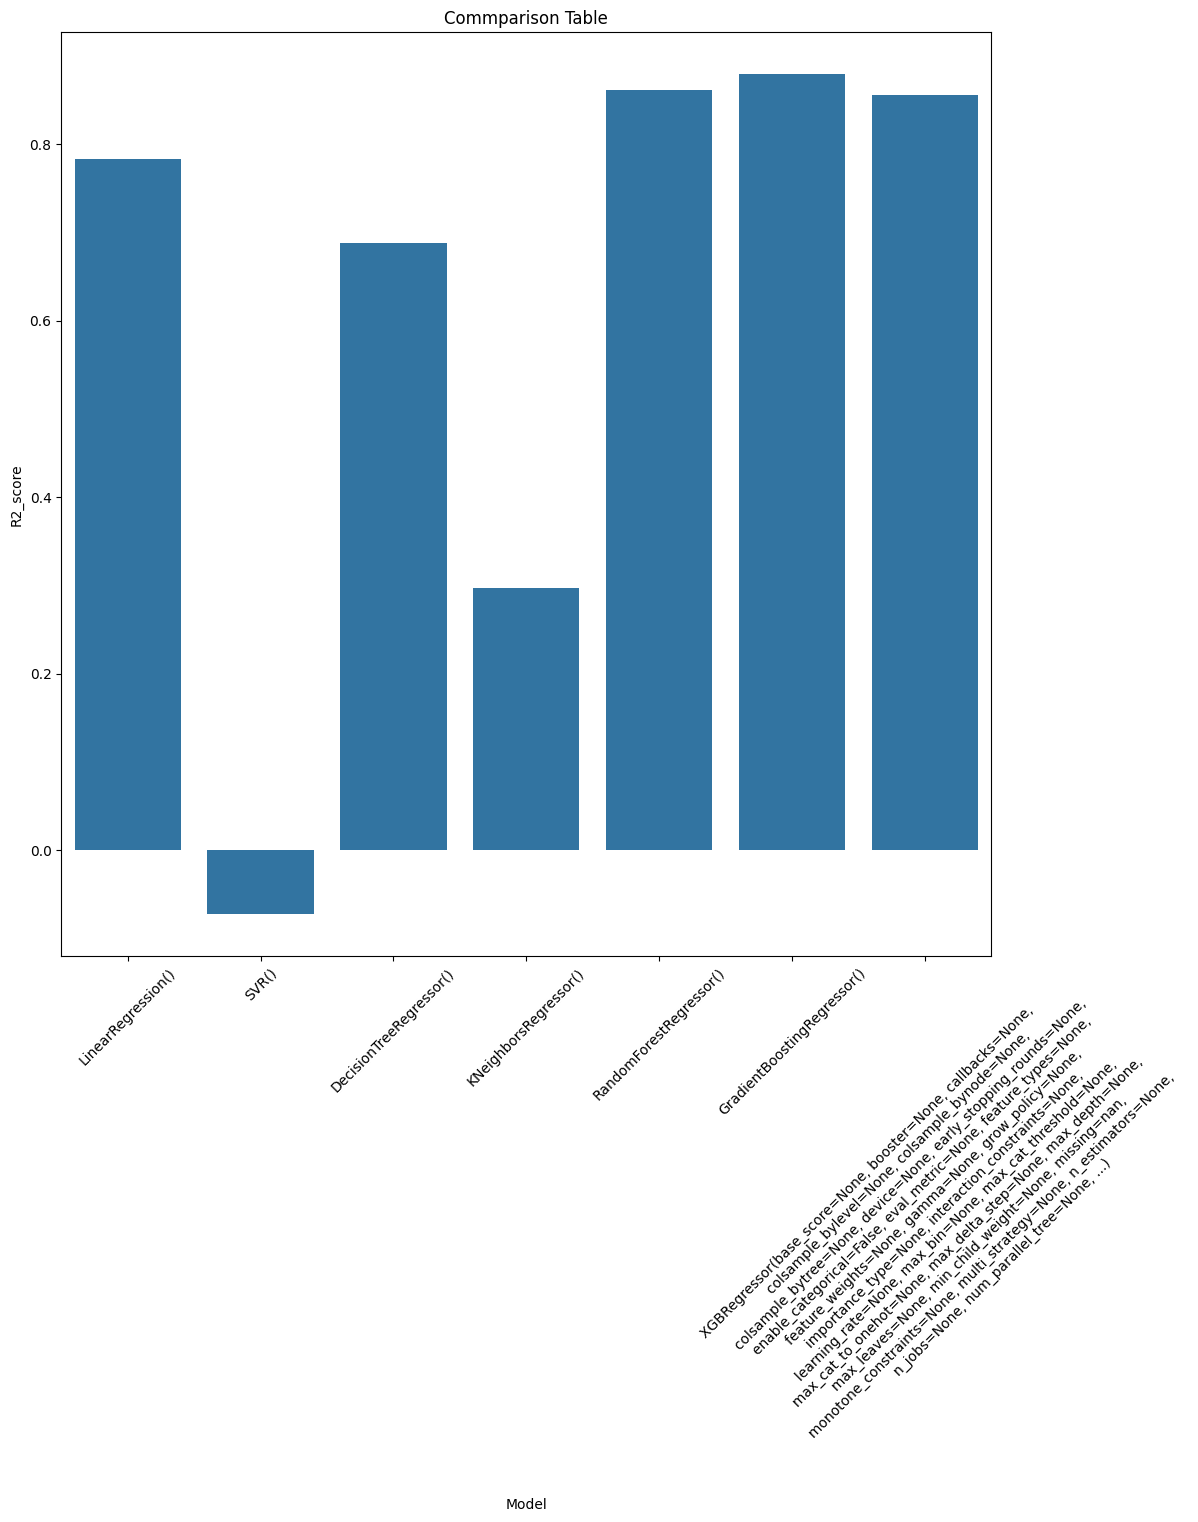

In [25]:
#check Accuracy Comparison
plt.figure(figsize=(12,12))
sns.barplot(x='Model',y='R2_score',data=result2_df)
plt.xticks(rotation=45)
plt.title('Commparison Table')
plt.show()

In [26]:
#Function for hyperparameter tuning
from sklearn.model_selection import GridSearchCV as GSV
best_model.Model=str(best_model.Model)
print(best_model.Model)
if(best_model.Model=='SVR()'):
    param_grid={
        'C':[0.1,1,10],
        'kernel':['linear','rbf']
    }
    grid=GSV(SVR(),param_grid,cv=5,scoring='r2')
    grid.fit(X_train,Y_train)
elif(best_model.Model=='SVC()'):
    param_grid={
        'C':[0.1,1,10],
        'kernel':['linear','rbf']                
    }
    grid=GSV(SVC(),param_grid,cv=5,scoring='accuracy')
    grid.fit(X_train,Y_train)
elif(best_model.Model=='DecisionTreeRegressor()'):
    param_grid={
        'max_depth':[None,5,10,20],
        'min_samples_split':[2,5,10]
    }
    grid=GSV(DecisionTreeRegressor(),param_grid,cv=5,scoring='r2')
    grid.fit(X_train,Y_train)
elif(best_model.Model=='DecisionTreeClassifier()'):
    param_grid={
        'max_depth':[None,5,10,20],
        'min_samples_split':[2,5,10]
    }
    grid=GSV(DTC(),param_grid,cv=5,scoring='accuracy')
    grid.fit(X_train,Y_train)
elif(best_model.Model=='KNeighborsRegressor()'):
    param_grid={
        'n_neighbors':[3,5,7,9],
        'weights':['uniform','distance']
    }
    grid=GSV(KNR(),param_grid,cv=5,scoring='r2')
    grid.fit(X_train,Y_train)
elif(best_model.Model=='KNeighborsClassifier()'):
    param_grid={
        'n_neighbors':[3,5,7,9],
        'weights':['uniform','distance']
    }
    grid=GSV(KNC(),param_grid,cv=5,scoring='accuracy')
    grid.fit(X_train,Y_train)
elif(best_model.Model=='GradientBoostingRegressor()'):
    param_grid={
        'max_depth':[3,5,7],
        'min_samples_split':[2,5,10],
        'n_estimators':[100,200,300],    
    }
    grid=GSV(GBR(),param_grid,cv=5,scoring='r2')
    grid.fit(X_train,Y_train)
elif(best_model.Model=='GradientBoostingClassifier()'):
    param_grid={
        'max_depth':[3,5,7],
        'min_samples_split':[2,5,10],
        'n_estimators':[100,200,300],    
    }
    grid=GSV(GBR(),param_grid,cv=5,scoring='accuracy')
    grid.fit(X_train,Y_train)
else:
    print('No need of Hypertuning')

GradientBoostingRegressor()


In [27]:
print(grid.best_params_)

{'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 100}


In [28]:
print(grid.best_score_)

0.8434538821389953


In [29]:
bg=grid.best_estimator_
bg.fit(X_train,Y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [30]:
Y_grid=bg.predict(X_test)
print('R2 score:-',r2_score(Y_test,Y_grid))

R2 score:- 0.8783387867111854


In [33]:
model=bg

In [34]:
import joblib
joblib.dump(model,'model.pkl')

['model.pkl']

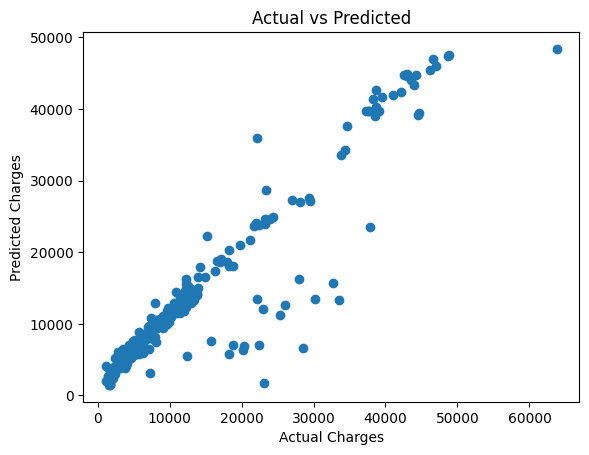

In [35]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, Y_grid)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")

plt.show()

In [36]:
joblib.dump(Hot,'Hot.pkl')

['Hot.pkl']